# Surprisal analysis of the rescuing solutions — witness_math, part 2

Continuation of [`witness_math.ipynb`](witness_math.ipynb). There we found that on AIME 24+25 the
answer hint "rescues" 20/47 blind-failed problems, but 31 of the 36 rescuing solutions are
**answer backfills** — only 3 problems survive the judge (`outputs_witness_math/judge_verdicts.json`).

Here we score **all 36 rescuing solutions** token by token under the frozen student and ask where
the student finds the privileged teacher's tokens incredibly unlikely:

- `d_t = log p(argmax) − log p(actual)` under the **blind** student prompt — the off-policy
  surprise PedRL's `G_spike` punishes;
- the **witness effect** `Δd_t = d_t(blind) − d_t(hinted)` — tokens that only become plausible
  *given* the answer.

Three analyses, split by judge verdict (legitimate / flawed / answer_backfill):

1. **Heatmaps** of `d_t` and `Δd_t` over token position, all 36 solutions.
2. **Maximum-surprisal regions** — the actual text spans where spikes live, rendered inline, plus
   whether they sit at the asserted `\boxed{}` answer (the backfill signature) or mid-derivation.
3. **`G_spike` by verdict** — if backfills score systematically lower, PedRL's learnability term
   already suppresses exactly the demonstrations the judge rejects, without needing a judge.

> Needs: `outputs_witness_math/judge_verdicts.json` (from part 1). Scoring needs a GPU
> (~72 forward passes of the 7B); results are cached to `outputs_witness_math/surprisal_gaps.json`,
> after which every plotting cell below runs CPU-only — download the cache to re-render locally.

In [1]:
%pip install -q -U "transformers>=4.49.0" "datasets>=2.19.0" "accelerate>=0.34.0" matplotlib
!nvidia-smi | head -12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 136.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 160.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 55.9 MB/s eta 0:00:00
Wed Jul  8 18:28:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|===============

In [2]:
# Get the repo (skipped when already inside it) and optional HF token
import os, sys

if os.path.basename(os.getcwd()) == "pedrl":
    os.chdir("..")
if os.path.basename(os.getcwd()) != "PedRL" and not os.path.exists("pedrl"):
    if not os.path.exists("PedRL"):
        !git clone https://github.com/dannyyoon0303/PedRL.git
    os.chdir("PedRL")
sys.path.insert(0, os.getcwd())

try:
    from google.colab import userdata
    try:
        os.environ.setdefault("HF_TOKEN", userdata.get("HF_TOKEN"))
    except Exception:
        pass
except ImportError:
    pass
print("cwd:", os.getcwd())

Cloning into 'PedRL'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 95 (delta 46), reused 72 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 1.30 MiB | 19.55 MiB/s, done.
Resolving deltas: 100% (46/46), done.
cwd: /content/PedRL


In [3]:
CFG = dict(
    model_name = "Qwen/Qwen2.5-7B-Instruct",   # must match the witness_math generation model
    out_dir = "outputs_witness_math",           # reads judge_verdicts.json, writes surprisal_gaps.json
    heatmap_bins = 220,        # token axis of the heatmaps is max-pooled into this many bins
    spike_beta = 5.0,          # PedRL defaults (pedrl/config.py)
    spike_lambda = 0.5,
    top_spikes = 10,           # spike tokens printed per displayed solution
    answer_window = 25,        # tokens around \\boxed{} counted as "answer-adjacent"
    show_keys = [],            # solutions to render inline; [] = auto-pick per category
)

## 1. Load the rescuing solutions and rebuild both prompts

The verdicts file carries each solution's completion token ids; we rebuild the blind (student) and
hinted (teacher) prompts exactly as in part 1, via `pedrl.data.build_prompts`.

In [6]:
import json, os, re
from datasets import load_dataset
from pedrl.data import build_prompts
from pedrl.modeling import load_tokenizer

verdict_path = os.path.join(CFG["out_dir"], "judge_verdicts.json")
assert os.path.exists(verdict_path), "run witness_math.ipynb (incl. the judge step) first"
with open(verdict_path) as f:
    verdicts = json.load(f)

def _boxed_int(s):
    m = re.findall(r"\\boxed\{(\d+)\}", s or "")
    return m[-1] if m else None

problems = {}
for name, year in [("math-ai/aime24", 2024), ("math-ai/aime25", 2025)]:
    for ex in load_dataset(name, split="test"):
        ans = ex.get("answer")
        ans = str(ans) if ans is not None else _boxed_int(ex.get("solution"))
        problems[f"{year}-{ex['id']}"] = {"problem": ex["problem"], "answer": ans}

tokenizer = load_tokenizer(CFG["model_name"])
seen = {}
items = []
for v in verdicts:
    p = problems[v["id"]]
    sp, tp = build_prompts(tokenizer, p["problem"], p["answer"], "", privileged="answer")
    seen[v["id"]] = seen.get(v["id"], -1) + 1
    items.append({
        "key": f"{v['id']}#{seen[v['id']]}",
        "id": v["id"], "category": v["category"], "answer": p["answer"],
        "student_prompt": sp, "teacher_prompt": tp,
        "completion": v["completion"], "ids": v["ids"],
    })

from collections import Counter
print(len(items), "rescuing solutions;", dict(Counter(i["category"] for i in items)))

README.md:   0%|          | 0.00/974 [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/30 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/878 [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

36 rescuing solutions; {'answer_backfill': 31, 'flawed': 1, 'legitimate': 4}


## 2. Per-token surprise gaps under both contexts (GPU once, then cached)

In [7]:
import numpy as np

gaps_path = os.path.join(CFG["out_dir"], "surprisal_gaps.json")

if os.path.exists(gaps_path):
    with open(gaps_path) as f:
        cache = json.load(f)
    print("loaded cached gaps — delete the file to rescore:", gaps_path)
else:
    import torch
    from pedrl.modeling import load_model
    model = load_model(CFG["model_name"])
    model.eval()

    @torch.no_grad()
    def token_gaps(prompt, completion_ids):
        device = next(model.parameters()).device
        p_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
        seq = torch.tensor([p_ids + list(completion_ids)], device=device)
        logits = model(input_ids=seq).logits[0]
        sl = logits[len(p_ids) - 1 : len(p_ids) - 1 + len(completion_ids)].float()
        logp = torch.log_softmax(sl, dim=-1)
        tgt = torch.tensor(completion_ids, device=device)
        actual = logp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
        return (logp.max(dim=-1).values - actual).cpu().numpy()

    cache = {}
    for n, it in enumerate(items):
        gb = token_gaps(it["student_prompt"], it["ids"])
        gh = token_gaps(it["teacher_prompt"], it["ids"])
        cache[it["key"]] = {"gap_blind": np.round(gb, 4).tolist(),
                            "gap_hint": np.round(gh, 4).tolist()}
        print(f"[{n+1:2d}/{len(items)}] {it['key']:12s} ({it['category'][:6]})  "
              f"mean d_t blind={gb.mean():.3f}  hinted={gh.mean():.3f}  "
              f"max Δd_t={(gb-gh).max():.2f}")
    with open(gaps_path, "w") as f:
        json.dump(cache, f)
    print("->", gaps_path)

for it in items:
    it["gap_blind"] = np.array(cache[it["key"]]["gap_blind"])
    it["gap_hint"] = np.array(cache[it["key"]]["gap_hint"])
    it["gap_diff"] = it["gap_blind"] - it["gap_hint"]

[modeling] incompatible torchao detected — disabled the peft torchao path


model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

[ 1/36] 2024-61#0    (answer)  mean d_t blind=0.079  hinted=0.068  max Δd_t=2.62
[ 2/36] 2024-63#0    (answer)  mean d_t blind=0.050  hinted=0.039  max Δd_t=8.88
[ 3/36] 2024-63#1    (answer)  mean d_t blind=0.052  hinted=0.039  max Δd_t=8.00
[ 4/36] 2024-70#0    (answer)  mean d_t blind=0.055  hinted=0.051  max Δd_t=4.25
[ 5/36] 2024-70#1    (answer)  mean d_t blind=0.083  hinted=0.070  max Δd_t=7.00
[ 6/36] 2024-71#0    (answer)  mean d_t blind=0.204  hinted=0.142  max Δd_t=11.00
[ 7/36] 2024-71#1    (answer)  mean d_t blind=0.233  hinted=0.203  max Δd_t=8.50
[ 8/36] 2024-74#0    (answer)  mean d_t blind=0.093  hinted=0.081  max Δd_t=5.00
[ 9/36] 2024-74#1    (answer)  mean d_t blind=0.167  hinted=0.135  max Δd_t=7.75
[10/36] 2024-75#0    (answer)  mean d_t blind=0.037  hinted=0.029  max Δd_t=3.75
[11/36] 2024-75#1    (answer)  mean d_t blind=0.045  hinted=0.035  max Δd_t=5.25
[12/36] 2024-76#0    (answer)  mean d_t blind=0.082  hinted=0.077  max Δd_t=2.88
[13/36] 2024-76#1    (answe

## 3. Heatmaps — all 36 rescuing solutions, grouped by verdict

Top: `d_t` under the blind student (sequential — darker = the student finds the token less
plausible). Bottom: the witness effect `Δd_t` (diverging — red = plausible only GIVEN the answer).
Rows are grouped legitimate → flawed → answer_backfill; the token axis is max-pooled so spikes
survive compression.

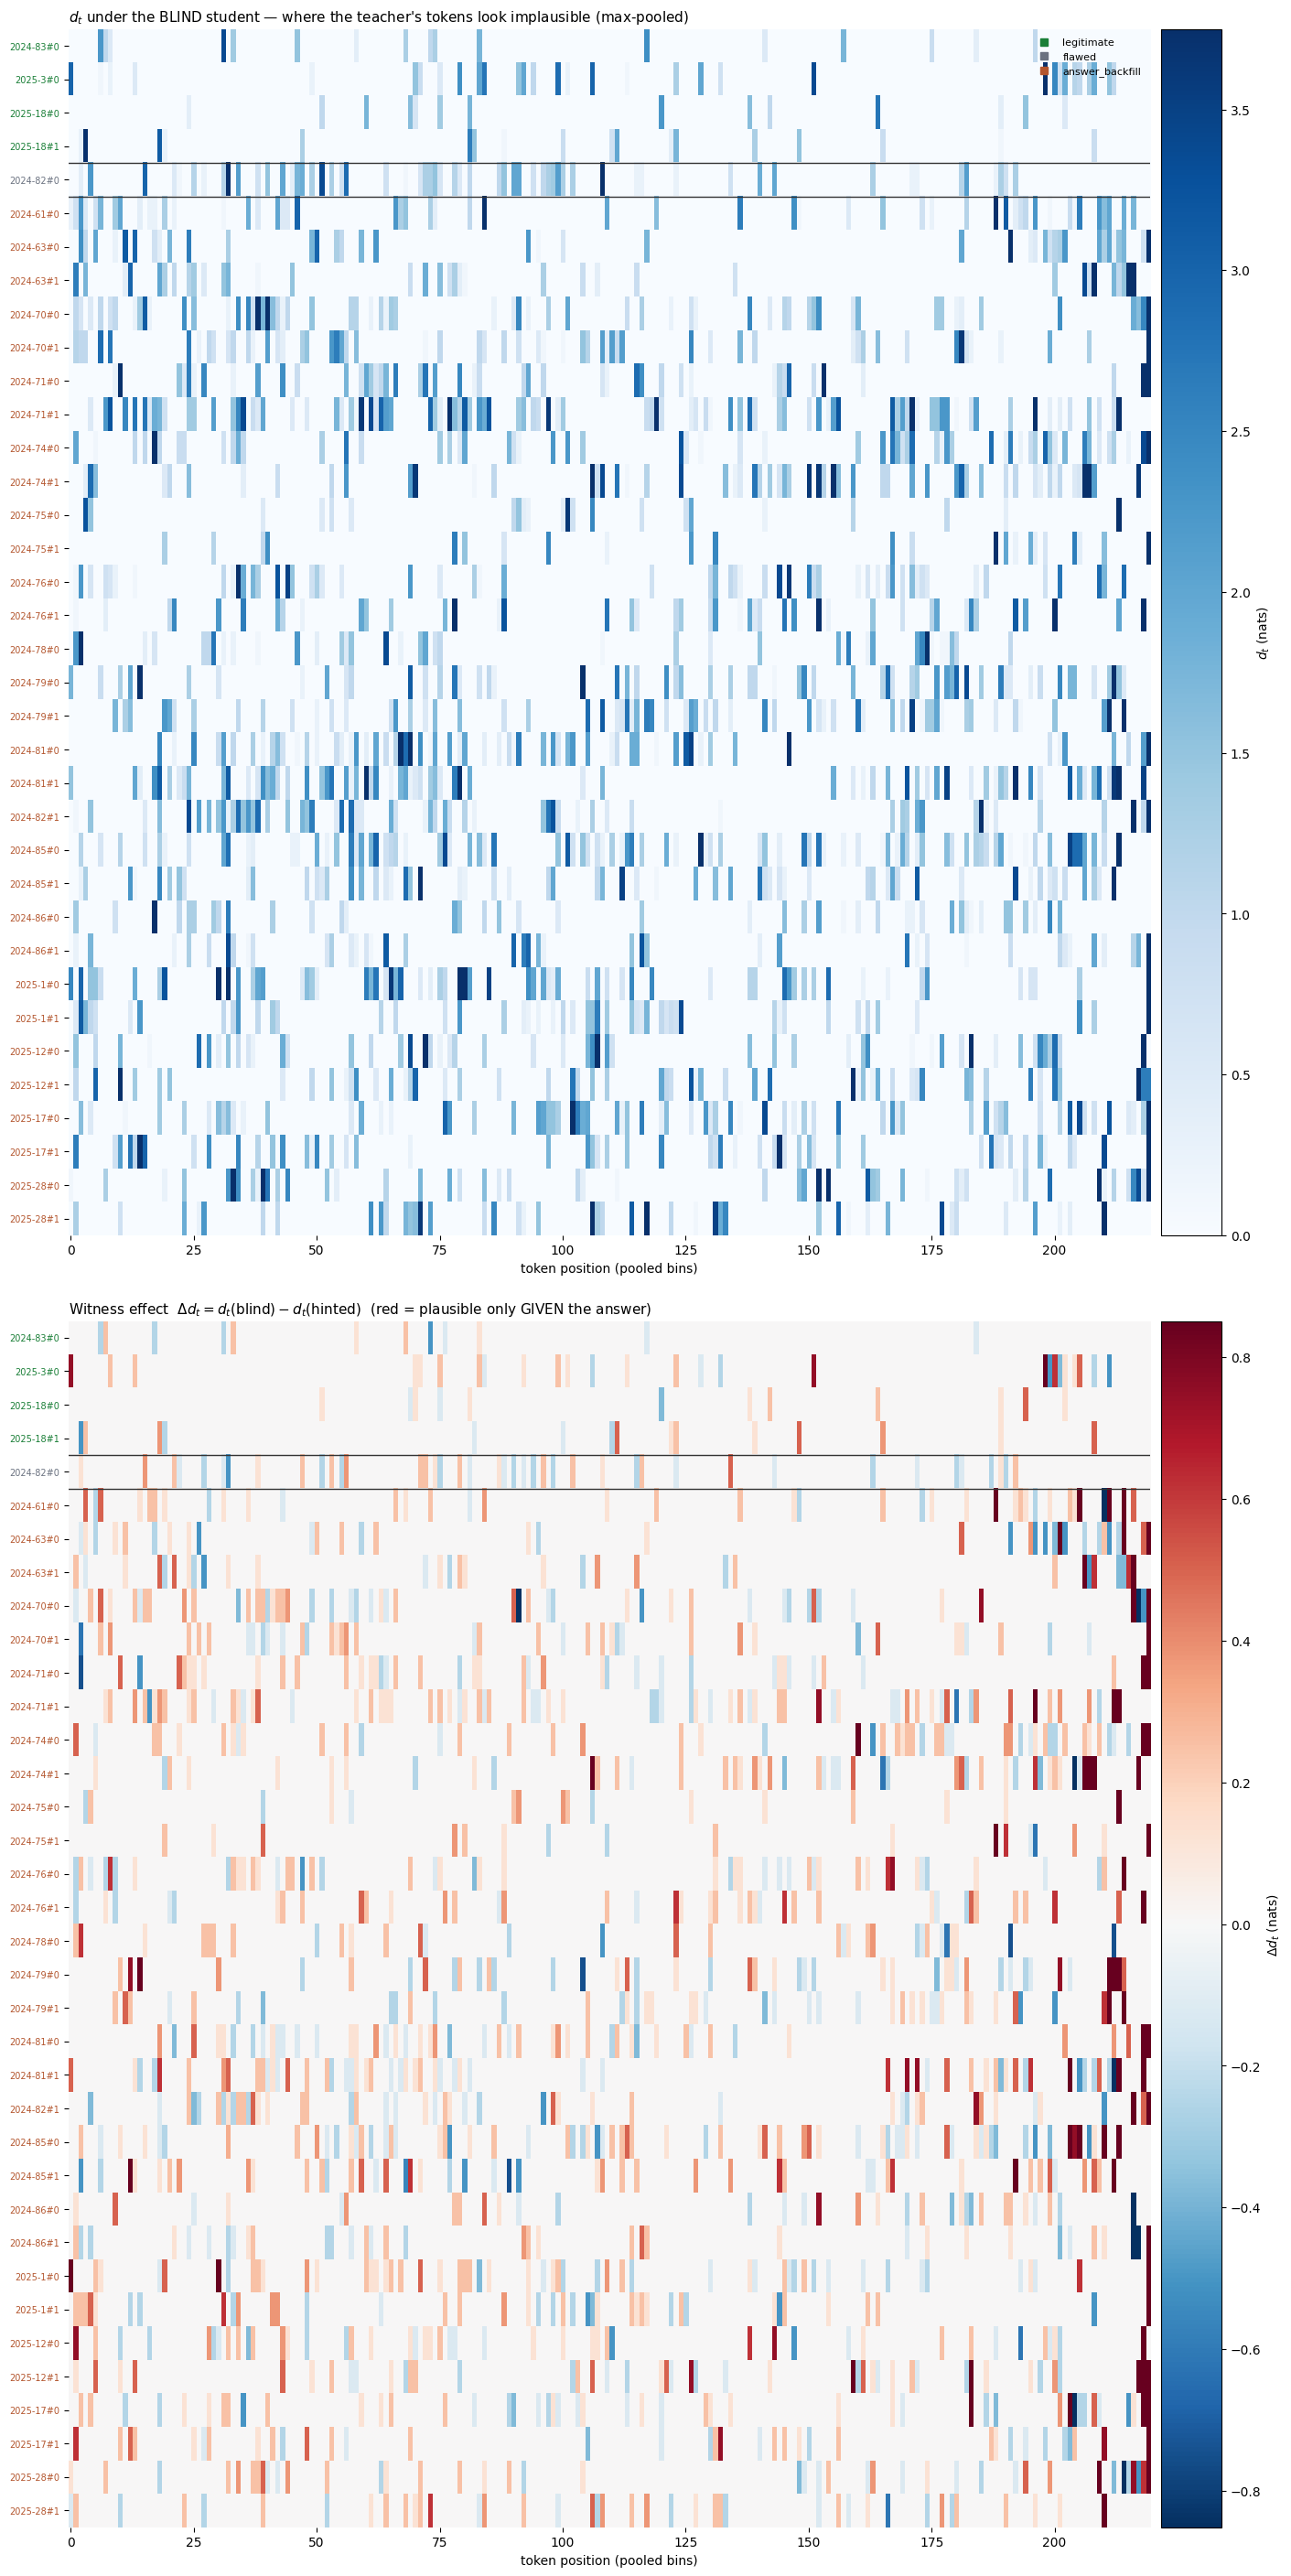

In [8]:
import matplotlib.pyplot as plt

CAT_ORDER = ["legitimate", "flawed", "answer_backfill"]
CAT_COLOR = {"legitimate": "#1a7f37", "flawed": "#6b7280", "answer_backfill": "#b3552d"}
ordered = [it for c in CAT_ORDER for it in items if it["category"] == c]

def pool(x, bins, signed=False):
    idx = np.linspace(0, len(x), bins + 1).astype(int)
    out = np.zeros(bins)
    for j in range(bins):
        seg = x[idx[j]:idx[j + 1]]
        if len(seg):
            out[j] = seg[np.argmax(np.abs(seg))] if signed else seg.max()
    return out

B = CFG["heatmap_bins"]
H_blind = np.stack([pool(it["gap_blind"], B) for it in ordered])
H_diff = np.stack([pool(it["gap_diff"], B, signed=True) for it in ordered])
labels = [it["key"] for it in ordered]
label_colors = [CAT_COLOR[it["category"]] for it in ordered]

fig, axes = plt.subplots(2, 1, figsize=(14, 0.32 * len(ordered) * 2 + 5), constrained_layout=True)

im0 = axes[0].imshow(H_blind, aspect="auto", cmap="Blues", vmin=0,
                     vmax=np.percentile(H_blind, 99), interpolation="nearest")
axes[0].set_title("$d_t$ under the BLIND student — where the teacher's tokens look implausible "
                  "(max-pooled)", fontsize=11, loc="left")
fig.colorbar(im0, ax=axes[0], label="$d_t$ (nats)", pad=0.01)

vmax = np.percentile(np.abs(H_diff), 99) or 1.0
im1 = axes[1].imshow(H_diff, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                     interpolation="nearest")
axes[1].set_title("Witness effect  $\\Delta d_t = d_t(\\mathrm{blind}) - d_t(\\mathrm{hinted})$"
                  "  (red = plausible only GIVEN the answer)", fontsize=11, loc="left")
fig.colorbar(im1, ax=axes[1], label="$\\Delta d_t$ (nats)", pad=0.01)

n_per = [sum(it["category"] == c for it in ordered) for c in CAT_ORDER]
for ax in axes:
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7)
    for tick, col in zip(ax.get_yticklabels(), label_colors):
        tick.set_color(col)
    y = -0.5
    for c, n in zip(CAT_ORDER, n_per):
        if n and y > -0.4:
            ax.axhline(y, color="#333", lw=1)
        y += n
    ax.set_xlabel("token position (pooled bins)")
    for s in ax.spines.values():
        s.set_visible(False)
handles = [plt.Line2D([0], [0], marker="s", ls="", color=CAT_COLOR[c], label=c) for c in CAT_ORDER]
axes[0].legend(handles=handles, loc="upper right", fontsize=8, frameon=False)
plt.show()

## 4. Maximum-surprisal regions — the text the student can't believe

Inline rendering: red background intensity ∝ `d_t` under the blind student. This shows exactly
which spans the frozen student finds incredibly unlikely — for backfills, expect the asserted
answer digits and the pivot phrases around them ("however, the correct value is ...") to burn red;
for legitimate solutions, expect isolated spikes at genuine reasoning forks.

In [9]:
import html as _html
from IPython.display import HTML, display

def render_solution(it, vmax=None):
    gaps = it["gap_blind"]
    vmax = vmax or max(1e-6, float(np.percentile(gaps, 99.5)))
    spans = []
    for t, g in zip(it["ids"], gaps):
        s = _html.escape(tokenizer.decode([t]))
        a = min(1.0, float(g) / vmax) * 0.85
        spans.append(f'<span style="background:rgba(214,69,45,{a:.2f});border-radius:2px">{s}</span>')
    header = (f'<b>{it["key"]}</b> — <span style="color:{CAT_COLOR[it["category"]]}">'
              f'{it["category"]}</span>, gold answer {it["answer"]}, '
              f'mean $d_t$={gaps.mean():.2f}, max={gaps.max():.1f} nats')
    display(HTML(f'<div style="margin:14px 0 4px">{header}</div>'
                 '<div style="font-family:monospace;font-size:12px;line-height:1.75;'
                 'white-space:pre-wrap;border:1px solid #ddd;border-radius:6px;padding:10px">'
                 + "".join(spans) + "</div>"))
    top = np.argsort(gaps)[::-1][:CFG["top_spikes"]]
    print(f"top-{CFG['top_spikes']} spike tokens (blind d_t):")
    for t in sorted(top):
        ctx = tokenizer.decode(it["ids"][max(0, t - 10):t])
        tok = tokenizer.decode([it["ids"][t]])
        print(f"  pos {t:4d}  d_t={gaps[t]:6.2f}   ...{ctx[-55:]!r} >>> {tok!r}")

if CFG["show_keys"]:
    to_show = [it for it in items if it["key"] in CFG["show_keys"]]
else:
    # auto-pick: per category, the solution with the largest max witness effect
    to_show = []
    for c in CAT_ORDER:
        cat = [it for it in items if it["category"] == c]
        if cat:
            to_show.append(max(cat, key=lambda it: it["gap_diff"].max()))
for it in to_show:
    render_solution(it)

top-10 spike tokens (blind d_t):
  pos    1  d_t=  3.00   ...'To' >>> ' find'
  pos  424  d_t=  2.38   ...'x = \\frac{3y}{4}\\' >>> ').'
  pos  456  d_t=  2.75   ...'\\) where \\(k\\) is an integer. Then' >>> ',\n'
  pos  498  d_t=  2.00   ...' are \\((3k, 4k)\\' >>> ').\n\n'
  pos  536  d_t=  2.88   ...':\n\\[-100 \\leq ' >>> '4'
  pos  573  d_t=  3.00   ...'k \\leq 100.\\]\n' >>> 'From'
  pos  689  d_t=  2.00   ...' 33.33\\). Therefore,' >>> ' the'
  pos  816  d_t=  3.38   ...' \\((-2m, 3m)\\).\n\n' >>> 'Similarly'
  pos 1068  d_t= 14.00   ...' 67 = 118.\\]\n\n' >>> 'However'
  pos 1076  d_t=  2.50   ...'.\\]\n\nHowever, we need to check if there' >>> ' is'


top-10 spike tokens (blind d_t):
  pos   19  d_t=  2.25   ...'f positive integers that satisfies the given conditions' >>> ':\n'
  pos   65  d_t=  3.00   ...' a positive integer that does not appear in the list' >>> '.\n\n'
  pos  133  d_t=  4.00   ...' number in the list. We will start by considering' >>> ' possible'
  pos  140  d_t=  2.12   ...'art by considering possible lengths of the list and the' >>> ' frequencies'
  pos  178  d_t=  2.00   ..." and the mode is 9, let's assume" >>> ' there'
  pos  213  d_t=  3.38   ...'k\\). We need to ensure that the median' >>> ' condition'
  pos  235  d_t=  2.88   ..."\nLet's try different values for \\(k\\" >>> '):\n'
  pos  410  d_t=  2.12   ...' is the average of the third and fourth numbers.' >>> ' We'
  pos  449  d_t=  3.88   ...' 9, 1, 1, ' >>> '8'
  pos  754  d_t=  2.12   ...' 9, 1, 3, ' >>> '9'


top-10 spike tokens (blind d_t):
  pos  267  d_t=  3.00   ...' Bottom-right\n\n### Step 4: Analyzing' >>> ' Shared'
  pos  361  d_t=  5.00   ...' Case 1: Top and Bottom Edges\n' >>> 'Let'
  pos  362  d_t=  2.62   ...' 1: Top and Bottom Edges\nLet' >>> '’s'
  pos  411  d_t=  2.62   ...' the bottom edge of the bottom row is red,' >>> ' then'
  pos  499  d_t=  3.38   ...' each configuration of the top and bottom edges, we' >>> ' have'
  pos  551  d_t=  2.75   ...':\n  - Left edge red, right edge blue' >>> ' ('
  pos  716  d_t=  3.12   ...' \\times 4 = 8\n\\]\n\n' >>> 'But'
  pos  724  d_t=  3.38   ...'\\]\n\nBut we need to re-evaluate the' >>> ' comb'
  pos  745  d_t=  3.25   ...' 6 ways to be colored, but the shared' >>> ' constraints'
  pos  771  d_t= 12.00   ...' correct count is:\n\\[\n\\boxed{8' >>> '2'


## 5. Where do the spikes live? The answer-adjacency signature

If backfilling is what the heatmap shows, the biggest witness-effect spikes should sit **at the
asserted answer**: the blind student cannot guess the boxed digits, while the hinted teacher finds
them trivial. For legitimate derivations the answer is *entailed* by the preceding steps, so the
gap at the box should be smaller and spikes should spread across the derivation.

share of top-5 witness-effect spikes within ±25 tokens of \boxed{}:
  legitimate      : 0.00   (n=4)
  flawed          : 0.00   (n=1)
  answer_backfill : 0.49   (n=31)


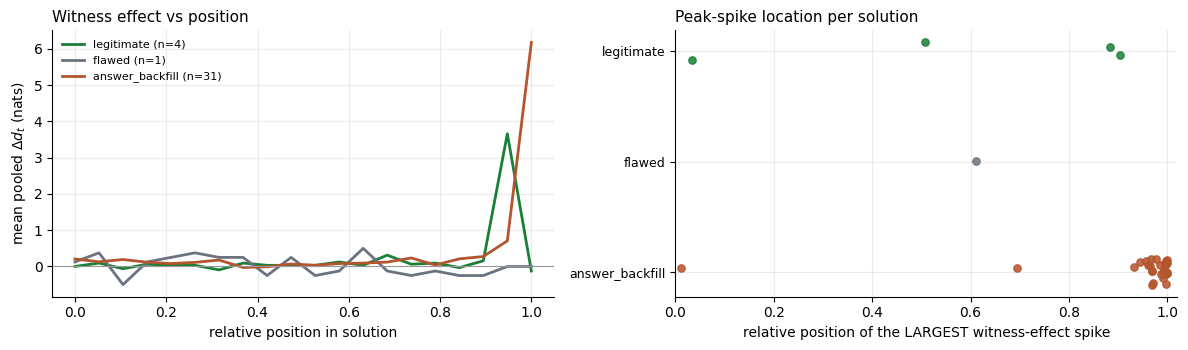

In [10]:
def boxed_token_index(it):
    pos = it["completion"].rfind("\\boxed")
    if pos < 0:
        return None
    lo, hi = 0, len(it["ids"])
    while lo < hi:
        mid = (lo + hi) // 2
        if len(tokenizer.decode(it["ids"][:mid], skip_special_tokens=True)) <= pos:
            lo = mid + 1
        else:
            hi = mid
    return max(0, lo - 1)

W = CFG["answer_window"]
rows = []
for it in items:
    bidx = boxed_token_index(it)
    n = len(it["ids"])
    top5 = np.argsort(it["gap_diff"])[::-1][:5]
    near = (np.abs(top5 - bidx) <= W).mean() if bidx is not None else np.nan
    rows.append({"key": it["key"], "category": it["category"], "n_tokens": n,
                 "boxed_idx": bidx, "top5_near_box": near,
                 "peak_rel_pos": float(np.argmax(it["gap_diff"])) / max(1, n - 1),
                 "mean_gap_blind": float(it["gap_blind"].mean()),
                 "gap_at_box": float(it["gap_blind"][bidx]) if bidx is not None else np.nan})

print(f"share of top-5 witness-effect spikes within ±{W} tokens of \\boxed{{}}:")
for c in CAT_ORDER:
    vals = [r["top5_near_box"] for r in rows if r["category"] == c and not np.isnan(r["top5_near_box"])]
    if vals:
        print(f"  {c:16s}: {np.mean(vals):.2f}   (n={len(vals)})")

# positional profile: mean witness effect by relative position, per category
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
NB = 20
for c in CAT_ORDER:
    cat = [it for it in items if it["category"] == c]
    if not cat:
        continue
    prof = np.zeros(NB)
    for it in cat:
        prof += pool(it["gap_diff"], NB, signed=True) / len(cat)
    axes[0].plot(np.linspace(0, 1, NB), prof, color=CAT_COLOR[c], lw=2,
                 label=f"{c} (n={len(cat)})")
axes[0].axhline(0, color="#999", lw=0.8)
axes[0].set_xlabel("relative position in solution")
axes[0].set_ylabel("mean pooled $\\Delta d_t$ (nats)")
axes[0].set_title("Witness effect vs position", fontsize=11, loc="left")
axes[0].legend(fontsize=8, frameon=False)

for i, c in enumerate(CAT_ORDER):
    vals = [r["peak_rel_pos"] for r in rows if r["category"] == c]
    axes[1].scatter(vals, np.full(len(vals), i) + np.random.uniform(-0.12, 0.12, len(vals)),
                    color=CAT_COLOR[c], s=28, alpha=0.85)
axes[1].set_yticks(range(len(CAT_ORDER)))
axes[1].set_yticklabels(CAT_ORDER, fontsize=9)
axes[1].set_xlabel("relative position of the LARGEST witness-effect spike")
axes[1].set_xlim(0, 1.02)
axes[1].invert_yaxis()
axes[1].set_title("Peak-spike location per solution", fontsize=11, loc="left")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 6. Does PedRL's `G_spike` already reject the backfills?

`G_spike` (spike-aware learnability, `pedrl/surprisal.py`) is exactly a soft-max over these
`d_t` gaps. If the judge-rejected backfills score systematically lower than the legitimate
derivations, then the `correctness × G_spike` reward — with no judge in the loop — already
down-weights the pathological demonstrations the witness produces in math.

legitimate      : mean G_spike = 0.2865   (n=4)
flawed          : mean G_spike = 0.2554   (n=1)
answer_backfill : mean G_spike = 0.0968   (n=31)


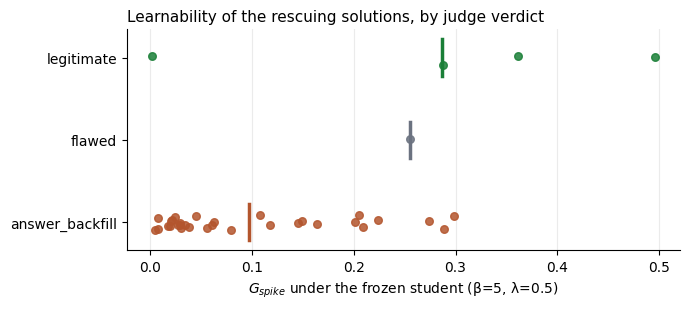

In [11]:
import torch
from pedrl.surprisal import spike_g_from_gaps

for it in items:
    it["g_spike"] = spike_g_from_gaps(torch.tensor(it["gap_blind"], dtype=torch.float32),
                                      beta=CFG["spike_beta"], lam=CFG["spike_lambda"])

fig, ax = plt.subplots(figsize=(7, 3.2))
for i, c in enumerate(CAT_ORDER):
    vals = [it["g_spike"] for it in items if it["category"] == c]
    if not vals:
        continue
    ax.scatter(vals, np.full(len(vals), i) + np.random.uniform(-0.1, 0.1, len(vals)),
               color=CAT_COLOR[c], s=30, alpha=0.85)
    ax.plot([np.mean(vals)] * 2, [i - 0.22, i + 0.22], color=CAT_COLOR[c], lw=2.5)
    print(f"{c:16s}: mean G_spike = {np.mean(vals):.4f}   (n={len(vals)})")
ax.set_yticks(range(len(CAT_ORDER)))
ax.set_yticklabels(CAT_ORDER, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("$G_{spike}$ under the frozen student (β=%.0f, λ=%.1f)" % (CFG["spike_beta"], CFG["spike_lambda"]))
ax.set_title("Learnability of the rescuing solutions, by judge verdict", fontsize=11, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 7. Reading the result

- **Heatmaps / regions:** for backfills, the blind student's largest gaps should sit on the
  asserted answer digits and the pivot phrases that precede them ("However, the correct value
  is…") — content that is *uncomputable* from the visible reasoning. For the 4 legitimate
  solutions, gaps should be lower overall and spikes should mark genuine forks in the derivation.
- **Answer adjacency:** a high share of top spikes within ±25 tokens of `\boxed{}` for backfills,
  and a peak-position scatter clustered near 1.0, is the quantitative signature that the hint's
  only effect is *where the solution lands*.
- **`G_spike`:** if legitimate > backfill with separation, PedRL's product reward
  `R × G_spike` is doing implicit judging — evidence that the mechanism transfers even to domains
  where raw correctness is gameable by echoing the witness. If there is *no* separation, math
  backfills are "plausible-sounding" to the student and the reward needs the executable/judge
  signal that debugging (PedRL_debug) gets for free.

Caveats: 36 solutions, one model; `flawed` has n=1; the two `2025-18` legitimate samples share a
problem, so legitimate spans only 3 distinct problems.